## Projected Tikhonov: Error vs. Rank $k$

In this notebook, I test out the error achieved when considering the projected problem
$$
\min_x \| K^+ K x - K^+ \tilde y \|_{M_\partial}^2 + \lambda^2 \| W x \|_M^2,
$$
where $\tilde y = y + \epsilon$, $y = K x$, $\tfrac{\| \epsilon \|}{\|y \|} = \delta$, for increasing target rank $k$. I also compare against a plain truncated SVD approach. From notebook `07_discrepancy_principle.ipynb`, I use $\nu_{dp} = 5$ to choose $\lambda_{dp}$. 

---

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from algorithms.matrix_free_rsvd import get_approximate_W

from utils.utils import progress_bar
from utils.solvers import fast_proj_solver_cg
from utils.problem_setup import TestProblemsSetup
from utils.metrics import error_auc_iou, error_movers
from utils.exact_forward_operator import ExactForwardOperator
from utils.projected_tikhonov import get_epsilon, discrepancy_principle
from utils.exact_forward_operator import ExactForwardOperator, fast_get_weights

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
FS = 13  # fontsize

In [23]:
def experiment(
        problem: dict,
        k_range: np.array,
        repeat: int = 1,
        delta: float = 0.01,
        nu: float = 5,
        seed = None
    ) -> pd.DataFrame:
    # Extract problem vars
    x, y = problem['x'], problem['y']
    rsvd, V_h = problem['rsvd'], problem['V_h']

    # Compute full SVD once and corresponding weights
    exact = ExactForwardOperator(V_h)
    Uf, Sf, Vtf = np.linalg.svd(exact.K, full_matrices=False)

    record = []
    step = 1
    n_steps = repeat * len(k_range)
    for r in range(repeat):
        # Generate a new y_tilde for each r
        epsilon = get_epsilon(y, delta, seed=seed + r)
        norm_epsilon = np.linalg.norm(epsilon)
        y_tilde = y + epsilon

        for k in k_range:
            progress_bar(step, n_steps, end_text=f' [{r=}, {k=}]')
            step += 1

            # Solve using rSVD
            U, S, Vt = rsvd.mf_rsvd(k=k, seed=seed + r)
            w = get_approximate_W(Vt.T, rsvd.M_dx)
            lam_dp_rsvd = discrepancy_principle(y_tilde, U, S, Vt.T, rsvd.M_dx, w, norm_epsilon, nu=nu)
            x_hat_rsvd = fast_proj_solver_cg(U, S, Vt.T, rsvd.M_dx, w, y_tilde, lambda_=lam_dp_rsvd)

            # Solve using truncated SVD
            U, S, Vt = Uf[:, :k], Sf[:k], Vtf[:k, :]
            w = fast_get_weights(S, Vt, exact.M_dx)
            lam_dp_svd = discrepancy_principle(y_tilde, U, S, Vt.T, exact.M_dx, w, norm_epsilon, nu=nu)
            x_hat_tsvd = fast_proj_solver_cg(U, S, Vt.T, exact.M_dx, w, y_tilde, lambda_=lam_dp_svd)
            
            record.append({
                'r': r,
                'k': k,
                'rsvd_euclidean': np.linalg.norm(x - x_hat_rsvd),
                'rsvd_emd': error_movers(x, x_hat_rsvd),
                'rsvd_auc_iou': error_auc_iou(x, x_hat_rsvd)[0],
                'tsvd_euclidean': np.linalg.norm(x - x_hat_tsvd),
                'tsvd_emd': error_movers(x, x_hat_tsvd),
                'tsvd_auc_iou': error_auc_iou(x, x_hat_tsvd)[0],
                'rsvd_lambda': lam_dp_rsvd,
                'tsvd_lambda': lam_dp_svd
            })
        
    return pd.DataFrame(record)


def save_plot(fig_name: str) -> None:
    if fig_name is not None:
        path = Path(f"../../figures/{fig_name}.png")
        if not path.exists():
            plt.savefig(path, dpi=300, bbox_inches="tight")
        else:
            print(path, 'already exists')


def plot_results(stats, title=True, s=2, figsize=(12, 4), fig_name=None):
    from matplotlib.lines import Line2D
    from utils.colors import C2, M, MS
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    metrics = ['euclidean', 'emd', 'auc_iou']
    for ax, me in zip(axes, metrics):
        for method, color in zip(['rsvd', 'tsvd'], C2):

            mean = stats[(f'{method}_{me}', 'mean')]
            std = stats[(f'{method}_{me}', 'std')]
            n = stats[(f'{method}_{me}', 'count')]

            sem = std / np.sqrt(n)
            ci = 1.96 * sem
            k_vals = stats.index

            # Line
            ax.plot(k_vals, mean, c=color, lw=1.75, alpha=0.5)
            
            # Markers
            ax.fill_between(k_vals, mean - ci, mean + ci, color=color, alpha=0.2)

            # Confidence interval
            ax.plot(k_vals[::s], mean.iloc[::s], M[0 if method=='rsvd' else 1],
                    c=color, ms=MS[0 if method=='rsvd' else 1])
        
        if title: ax.set_title(me)
        ax.grid(True, alpha=0.5)
    
    # Custom labels
    handles, labels = [], []
    for i, method in enumerate(['rsvd', 'tsvd']):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))
        labels.append('rSVD' if method == 'rsvd' else 'tSVD')


    #axes[1].legend()
    axes[1].legend(handles=handles, labels=labels)
    axes[1].set_xlabel('Rank $k$')

    plt.tight_layout()
    save_plot(fig_name)
    plt.show()


In [3]:
setup = TestProblemsSetup(n=32)
problems = setup.get_test_problems()
problem_params = setup.problem_params
results_path = Path('../../results')

In [29]:
run = False
repeat = 100
k_range = np.arange(5, 100, 5)

file_path = results_path / f'projected_tikhonov_I_r{repeat}.csv'
if run:
    dfI = experiment(
        problem=problems['I'],
        k_range=k_range,
        repeat=repeat,
        seed=SEED,
        nu=10
    )
    dfI.to_csv(file_path)
else:
    dfI = pd.read_csv(file_path)

In [5]:
metrics = [
    "rsvd_euclidean",
    "rsvd_emd",
    "rsvd_auc_iou",
    "tsvd_euclidean",
    "tsvd_emd",
    "tsvd_auc_iou",
]

../../figures/projected_noisy_error_I.png already exists


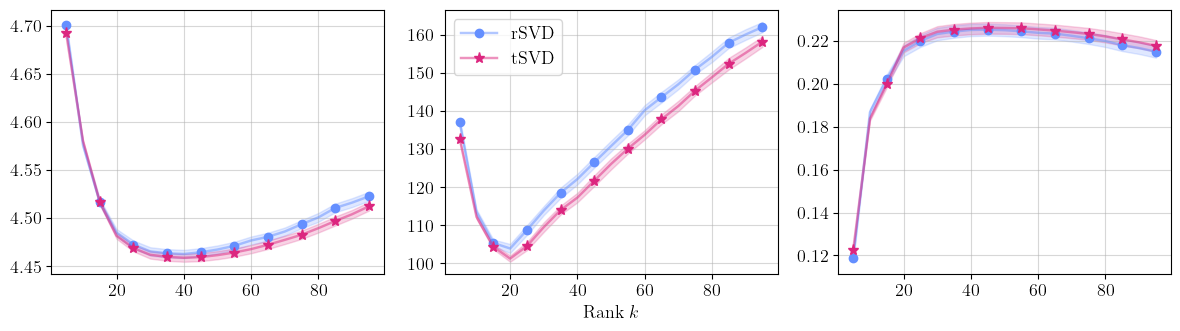

In [26]:
stats = dfI.groupby("k")[metrics].agg(["mean", "std", "count"])
plot_results(stats, title=False, figsize=(12, 3.5), fig_name='projected_noisy_error_I')

In [7]:
file_path = results_path / f'projected_tikhonov_II_r{repeat}.csv'
if run:
    dfII = experiment(
        problem=problems['II'],
        k_range=k_range,
        repeat=repeat,
        seed=SEED,
        nu=10
    )
    dfII.to_csv(file_path)
else:
    dfII = pd.read_csv(file_path)

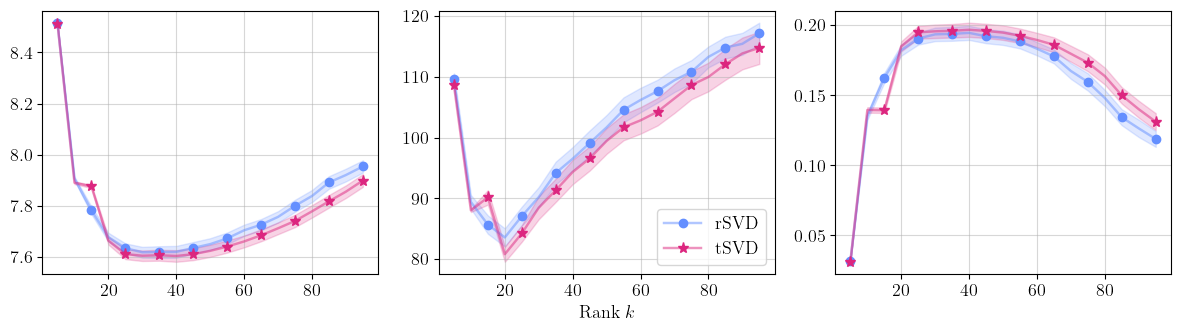

In [27]:
statsII = dfII.groupby("k")[metrics].agg(["mean", "std", "count"])
plot_results(statsII, title=False, figsize=(12, 3.5), fig_name='projected_noisy_error_II')

In [9]:
file_path = results_path / f'projected_tikhonov_III_r{repeat}.csv'
if run:
    dfIII = experiment(
        problem=problems['III'],
        k_range=k_range,
        repeat=repeat,
        seed=SEED,
        nu=10
    )
    dfIII.to_csv(file_path)
else:
    dfIII = pd.read_csv(file_path)

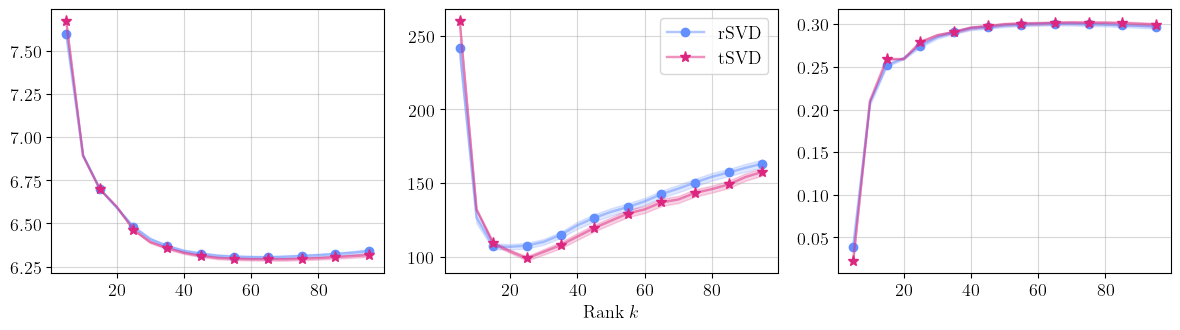

In [30]:
statsIII = dfIII.groupby("k")[metrics].agg(["mean", "std", "count"])
plot_results(statsIII, title=False, figsize=(12, 3.5), fig_name='projected_noisy_error_III')

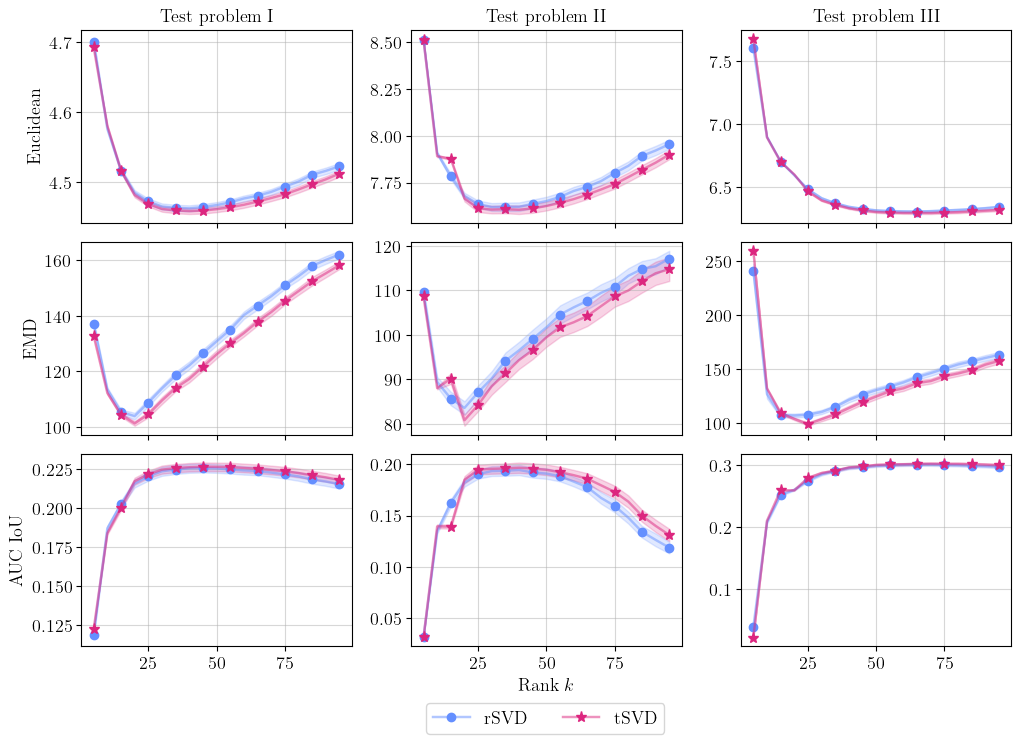

In [86]:
def plot_results2(stats_dict, title=True, s=2, figsize=(12, 4), fig_name=None):
    from matplotlib.lines import Line2D
    from utils.colors import C2, M, MS

    fig, axes_all = plt.subplots(
        3, 3, figsize=figsize, sharex=True
    )

    metrics = ['euclidean', 'emd', 'auc_iou']

    for i, pid in enumerate(['I', 'II', 'III']):

        stats = stats_dict[pid]
        axes = axes_all[:, i]
        for ax, me in zip(axes, metrics):
            for method, color in zip(['rsvd', 'tsvd'], C2):

                mean = stats[(f'{method}_{me}', 'mean')]
                std = stats[(f'{method}_{me}', 'std')]
                n = stats[(f'{method}_{me}', 'count')]

                sem = std / np.sqrt(n)
                ci = 1.96 * sem
                k_vals = stats.index

                # Line
                ax.plot(k_vals, mean, c=color, lw=1.75, alpha=0.5)
                
                # Markers
                ax.fill_between(k_vals, mean - ci, mean + ci, color=color, alpha=0.2)

                # Confidence interval
                ax.plot(k_vals[::s], mean.iloc[::s], M[0 if method=='rsvd' else 1],
                        c=color, ms=MS[0 if method=='rsvd' else 1])
                
                ax.grid(True, alpha=0.5)
    
    # Custom labels
    handles, labels = [], []
    for i, method in enumerate(['rsvd', 'tsvd']):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=1.75, alpha=0.5)
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))
        labels.append('rSVD' if method == 'rsvd' else 'tSVD')

    axes_all[2][1].legend(
        handles=handles, labels=labels,
        loc='upper right', ncols=2, bbox_to_anchor=(0.97, -0.25))
    axes_all[2][1].set_xlabel('Rank $k$')

    axes_all[0][0].set_title('Test problem I', fontsize=FS)
    axes_all[0][1].set_title('Test problem II', fontsize=FS)
    axes_all[0][2].set_title('Test problem III', fontsize=FS)

    axes_all[0][0].set_ylabel('Euclidean', fontsize=FS)
    axes_all[1][0].set_ylabel('EMD', fontsize=FS)
    axes_all[2][0].set_ylabel('AUC IoU', fontsize=FS)

    #plt.tight_layout()
    plt.subplots_adjust(wspace=0.22, hspace=0.1)
    save_plot(fig_name)
    plt.show()

stats_dict = {'I': stats, 'II': statsII, 'III': statsIII}

plot_results2(stats_dict, title=False, figsize=(12, 8), fig_name='projected_noisy_error_all')

---

In [17]:
repeat = 10
k_range = np.arange(5, 10, 1)

df = experiment(
    problem=problems['II'],
    k_range=k_range,
    repeat=repeat,
    nu=5,
    seed=SEED
)

[##############################] 50/50 [r=9, k=9]


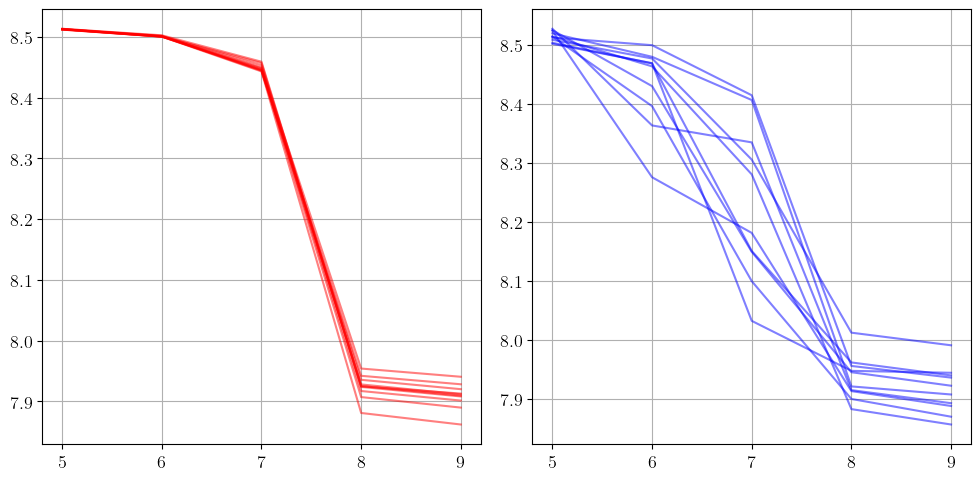

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

for r in range(repeat):
    data = df[df.r == r]
    ax1.plot(data.k, data.tsvd_euclidean, c='r', alpha=.5)
    ax2.plot(data.k, data.rsvd_euclidean, c='b', alpha=.5)
    ax1.grid(True)
    ax2.grid(True)

plt.tight_layout()

In [12]:
from fenics import Function, plot

def debug(
        problem: dict,
        k: int,
        r: int = 1,
        delta: float = 0.01,
        nu: float = 10,
        seed = 15
    ):
    from fenics import Function

    # Extract problem vars
    x, y = problem['x'], problem['y']
    rsvd, V_h = problem['rsvd'], problem['V_h']

    # Compute full SVD once and corresponding weights
    exact = ExactForwardOperator(V_h)
    Uf, Sf, Vtf = np.linalg.svd(exact.K, full_matrices=False)

    # Generate y_tilde
    epsilon = get_epsilon(y, delta, seed=seed + r)
    norm_epsilon = np.linalg.norm(epsilon)
    y_tilde = y + epsilon

    # Solve using rSVD
    U, S, Vt = rsvd.mf_rsvd(k=k, seed=seed + r)
    w = get_approximate_W(Vt.T, rsvd.M_dx)
    lam_dp = discrepancy_principle(y_tilde, U, S, Vt.T, rsvd.M_dx, w, norm_epsilon, nu=nu)
    x_hat_rsvd = fast_proj_solver_cg(U, S, Vt.T, rsvd.M_dx, w, y_tilde, lambda_=lam_dp)

    # Solve using truncated SVD
    U, S, Vt = Uf[:, :k], Sf[:k], Vtf[:k, :]
    w = fast_get_weights(S, Vt, exact.M_dx)
    lam_dp = discrepancy_principle(y_tilde, U, S, Vt.T, exact.M_dx, w, norm_epsilon, nu=nu)
    x_hat_tsvd = fast_proj_solver_cg(U, S, Vt.T, exact.M_dx, w, y_tilde, lambda_=lam_dp)
    f_tsvd, f_rsvd = Function(V_h), Function(V_h)
    f_tsvd.vector()[:], f_rsvd.vector()[:] = x_hat_tsvd, x_hat_rsvd
    return f_tsvd, f_rsvd
    

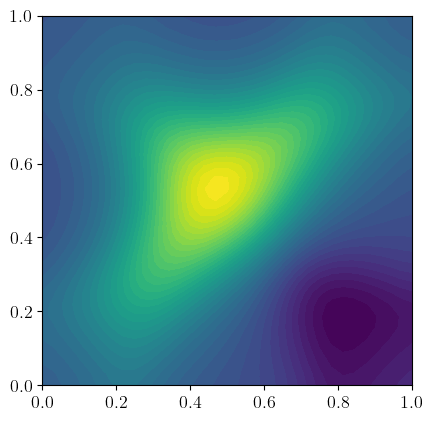

In [22]:
f_tsvd, f_rsvd = debug(
    problem=problems['II'], k=7, r=0
)

plot(f_tsvd)

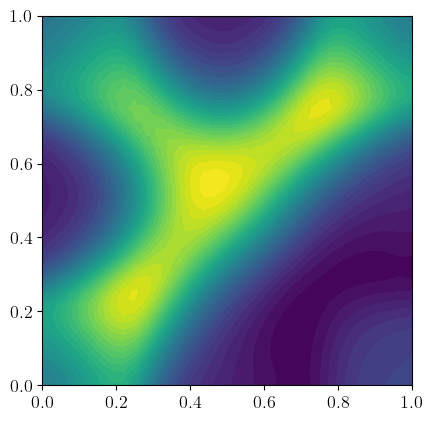

In [16]:
f_tsvd, f_rsvd = debug(
    problem=problems['II'], k=8, r=0
)

plot(f_tsvd)